In [30]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import pandas as pd

import re
from pathlib import Path
from typing import Dict, List, Optional


In [39]:
dtypes = ["float32", "float64"]
devices = ["cpu", "cuda"]

def parse_file(data):
    cols = data.columns
    steps = data[cols[0]][1:].astype(float).to_numpy()
    mean = data[cols[1]][1:].astype(float).to_numpy()
    std = data[cols[2]][1:].astype(float).to_numpy()
    return [steps, mean, std]


def open_files(
    path: str,
    example_name: str,
    dtypes: Optional[list] = None,
    devices: Optional[list] = None
) -> Dict[str, Dict[str, pd.DataFrame]]:
    """
    Takes an example name (e.g., 'example_1') and returns 4 CSV files 
    opened as pandas DataFrames.
    
    Returns: {device: {dtype: DataFrame}}
    """
    if dtypes is None:
        dtypes = ["float32", "float64"]
    if devices is None:
        devices = ["cpu", "cuda"]
    
    source_path = Path(path)
    result = {}
    
    for device in devices:
        result[device] = {}
        for dtype in dtypes:
            filename = f"{example_name}_{device}_dtype_{dtype}.csv"
            file_path = source_path / filename
            
            if file_path.exists():
                result[device][dtype] = pd.read_csv(file_path)
            else:
                # Try with torch. prefix if direct match fails
                filename_torch = f"{example_name}_{device}_dtype_torch.{dtype}.csv"
                file_path_torch = source_path / filename_torch
                
                if file_path_torch.exists():
                    result[device][dtype] = parse_file(pd.read_csv(file_path_torch))
                else:
                    result[device][dtype] = None
                
    return result

open_files("", "example_1")["cpu"]["float32"]

[array([0., 1., 2., 3.]),
 array([  13.84215457,   30.09978178,  140.56659292, 2593.76085211]),
 array([2.70170996e-01, 3.00708193e+00, 1.30996676e+01, 2.88581579e+02])]

In [40]:
out = open_files("", "example_5_RWA")["cpu"]["float32"]

In [ ]:
open_files("", "example_1")["cpu"]["float32"]

# 1. Example 1

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


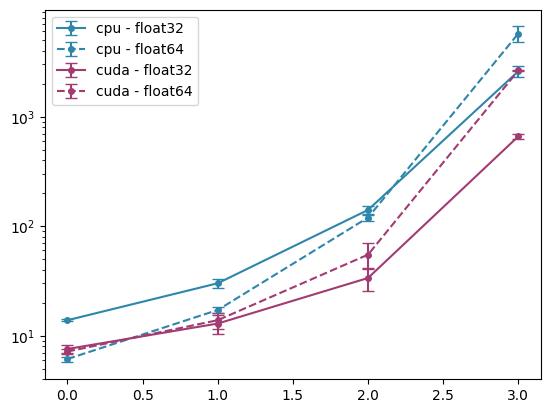

In [3]:
colors = {"cpu": "#2E86AB", "cuda": "#A23B72"}
linestyles = {"float32": "-", "float64": "--"}

for device in devices:
    for dtype in dtypes:
        data = open_files("", "example_1")[device][dtype]
        plt.errorbar(
            data[0], data[1], yerr=data[2],
            label=f"{device} - {dtype}",
            color=colors[device],           # Color by device
            linestyle=linestyles[dtype],    # Style by dtype
            capsize=4, capthick=1,
            marker='o', markersize=4, linewidth=1.5
        )
        plt.yscale("log")
plt.ylim(bottom=4)
plt.legend()
plt.savefig("example_1_figure.eps")

In [ ]:
open_files("", "example_1")["cpu"]["float64"]

In [16]:
open_files("", "example_1")["cuda"]["float64"][1] / open_files("", "example_1")["cuda"]["float32"][1]

array([0.94750458, 1.072879  , 1.63370637, 3.99143374])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


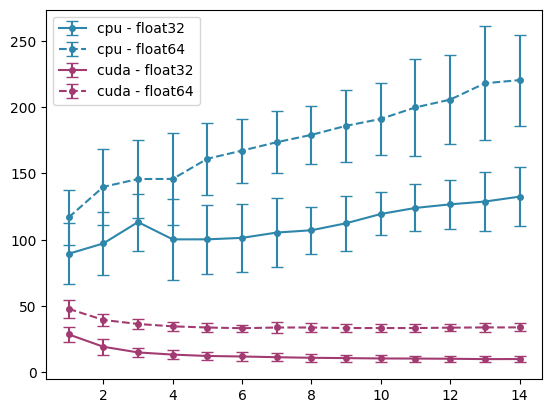

In [5]:
colors = {"cpu": "#2E86AB", "cuda": "#A23B72"}
linestyles = {"float32": "-", "float64": "--"}

for device in devices:
    for dtype in dtypes:
        data = open_files("", "example_2")[device][dtype]
        if device == "cpu":
            data[2] = data[2]
        plt.errorbar(
            data[0], data[1], yerr=data[2],
            label=f"{device} - {dtype}",
            color=colors[device],           # Color by device
            linestyle=linestyles[dtype],    # Style by dtype
            capsize=4, capthick=1,
            marker='o', markersize=4, linewidth=1.5
        )
plt.legend()
plt.savefig("example_2_figure.eps")

In [22]:
open_files("", "example_2")["cpu"]["float64"][1][0] / open_files("", "example_2")["cuda"]["float32"][1][-1]

11.714156885130304

In [7]:
open_files("", "example_2")["cpu"]["float64"][1] / open_files("", "example_2")["cpu"]["float32"][1]

array([1.30677366, 1.4394787 , 1.28651408, 1.45476938, 1.60639434,
       1.6490073 , 1.64682124, 1.67161035, 1.65386334, 1.60057402,
       1.61155054, 1.62371833, 1.69272483, 1.6638816 ])

In [14]:
open_files("", "example_2")["cuda"]["float64"][1] / open_files("", "example_2")["cuda"]["float32"][1]

array([1.67478782, 2.05029249, 2.43365766, 2.59758173, 2.75027969,
       2.7901852 , 2.97392292, 3.09271527, 3.1243981 , 3.20393835,
       3.22817672, 3.30172958, 3.40798618, 3.39407718])

In [19]:
open_files("", "example_2")["cuda"]["float32"][0] / open_files("", "example_2")["cuda"]["float32"][-1]

array([0.16854048, 0.32326199, 0.86261317, 1.2936631 , 1.52526704,
       1.7764481 , 2.35119224, 2.86323316, 3.47587001, 3.38071747,
       4.82950198, 5.59434878, 5.81129223, 5.40848914])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


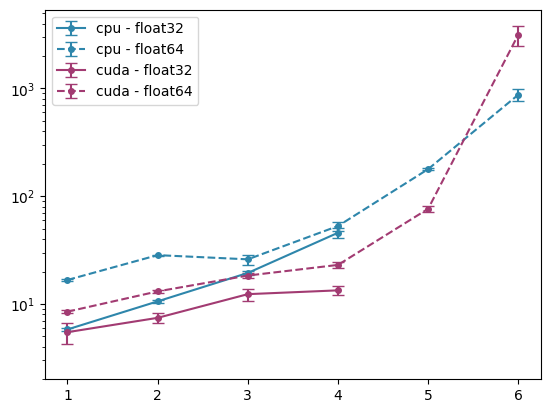

In [38]:
colors = {"cpu": "#2E86AB", "cuda": "#A23B72"}
linestyles = {"float32": "-", "float64": "--"}

for device in devices:
    for dtype in dtypes:
        data = open_files("", "example_3")[device][dtype]
        plt.errorbar(
            data[0], data[1], yerr=data[2] / 2,
            label=f"{device} - {dtype}",
            color=colors[device],           # Color by device
            linestyle=linestyles[dtype],    # Style by dtype
            capsize=4, capthick=1,
            marker='o', markersize=4, linewidth=1.5
        )
        plt.yscale("log")
plt.ylim(bottom=2)
plt.legend()
plt.savefig("example_3_figure.eps")

In [9]:
open_files("", "example_3")["cpu"]["float64"][1] / open_files("", "example_3")["cuda"]["float64"][1]
open_files("", "example_3")["cpu"]["float64"][1][:-2] / open_files("", "example_3")["cpu"]["float32"][1]

array([2.87877036, 2.68538339, 1.337916  , 1.15474242])

In [13]:
open_files("", "example_3")["cuda"]["float64"][1][:-2] / open_files("", "example_3")["cuda"]["float32"][1]

array([1.55020394, 1.75946558, 1.48778839, 1.72206279])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


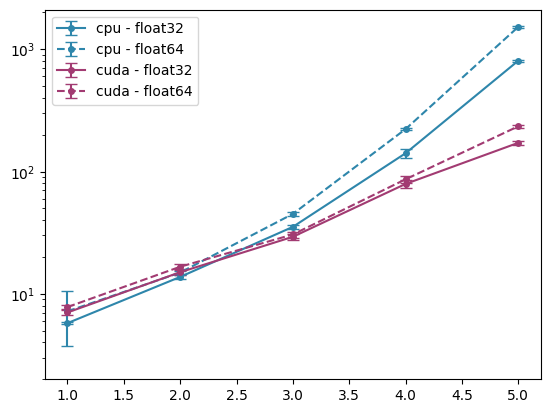

In [39]:
colors = {"cpu": "#2E86AB", "cuda": "#A23B72"}
linestyles = {"float32": "-", "float64": "--"}


for device in devices:
    for dtype in dtypes:
        data = open_files("", "example_4")[device][dtype]
        plt.errorbar(
            data[0], data[1], yerr=data[2] / 2,
            label=f"{device} - {dtype}",
            color=colors[device],           # Color by device
            linestyle=linestyles[dtype],    # Style by dtype
            capsize=4, capthick=1,
            marker='o', markersize=4, linewidth=1.5
        )
        plt.yscale("log")
        
plt.ylim(bottom=2)
plt.legend()
plt.savefig("example_4_figure.eps")

In [10]:
open_files("", "example_4")["cpu"]["float64"][1] / open_files("", "example_4")["cuda"]["float32"][1]
open_files("", "example_4")["cpu"]["float64"][1] / open_files("", "example_4")["cpu"]["float32"][1]

array([1.24761959, 1.08560723, 1.27651464, 1.57635547, 1.89112222])

In [11]:
open_files("", "example_4")["cuda"]["float64"][1] / open_files("", "example_4")["cuda"]["float32"][1]

array([1.1070888 , 1.10798653, 1.04474655, 1.09115053, 1.36474261])

### TimeResolved analysis

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


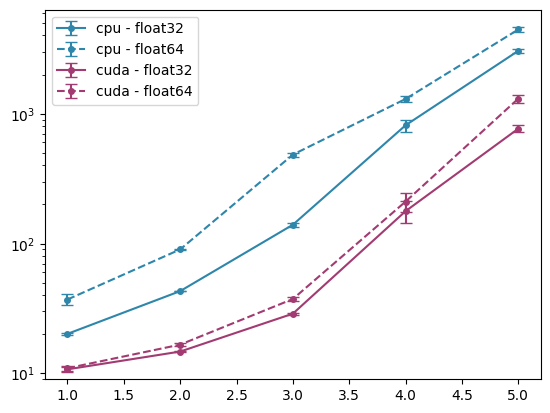

In [63]:
colors = {"cpu": "#2E86AB", "cuda": "#A23B72"}
linestyles = {"float32": "-", "float64": "--"}


for device in devices:
    for dtype in dtypes:
        data = open_files("", "example_5_kinetic")[device][dtype]
        plt.errorbar(
            data[0], data[1], yerr=data[2] / 2,
            label=f"{device} - {dtype}",
            color=colors[device],           # Color by device
            linestyle=linestyles[dtype],    # Style by dtype
            capsize=4, capthick=1,
            marker='o', markersize=4, linewidth=1.5
        )
        plt.yscale("log")
        
plt.ylim(bottom=9)
plt.legend()
plt.savefig("example_5_kinetic.eps")

In [64]:
open_files("", "example_5_kinetic")["cpu"]["float64"][1] / open_files("", "example_5_kinetic")["cuda"]["float32"][1]

array([ 3.45030756,  6.11864366, 16.78656407,  7.3127952 ,  5.80207372])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


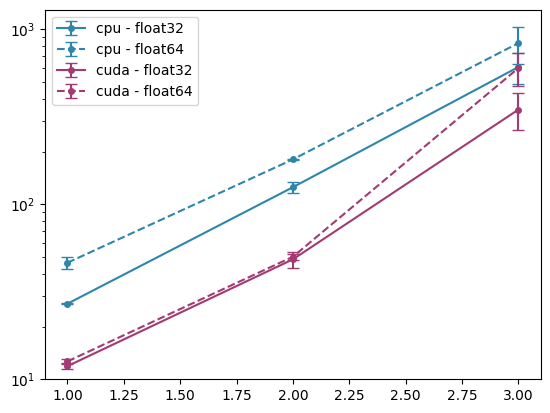

In [65]:
colors = {"cpu": "#2E86AB", "cuda": "#A23B72"}
linestyles = {"float32": "-", "float64": "--"}


for device in devices:
    for dtype in dtypes:
        data = open_files("", "example_5_RWA")[device][dtype]
        plt.errorbar(
            data[0], data[1], yerr=data[2] / 2,
            label=f"{device} - {dtype}",
            color=colors[device],           # Color by device
            linestyle=linestyles[dtype],    # Style by dtype
            capsize=4, capthick=1,
            marker='o', markersize=4, linewidth=1.5
        )
        plt.yscale("log")
        
plt.ylim(bottom=10)
plt.legend()
plt.savefig("example_5_RWA.eps")

In [66]:
open_files("", "example_5_RWA")["cpu"]["float64"][1] / open_files("", "example_5_RWA")["cuda"]["float32"][1]

array([3.89715471, 3.72497543, 2.39977212])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


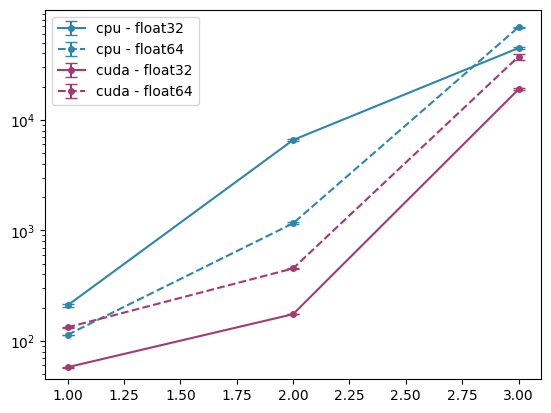

In [70]:
colors = {"cpu": "#2E86AB", "cuda": "#A23B72"}
linestyles = {"float32": "-", "float64": "--"}


for device in devices:
    for dtype in dtypes:
        data = open_files("", "example_5_propagator")[device][dtype]
        plt.errorbar(
            data[0], data[1], yerr=data[2] / 2,
            label=f"{device} - {dtype}",
            color=colors[device],           # Color by device
            linestyle=linestyles[dtype],    # Style by dtype
            capsize=4, capthick=1,
            marker='o', markersize=4, linewidth=1.5
        )
        plt.yscale("log")
        
plt.ylim(bottom=45)
plt.legend()
plt.savefig("example_5_propagator.eps")

In [71]:
open_files("", "example_5_propagator")["cpu"]["float64"][1] / open_files("", "example_5_propagator")["cuda"]["float32"][1]

array([1.96563316, 6.63538177, 3.65302041])